In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00000
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


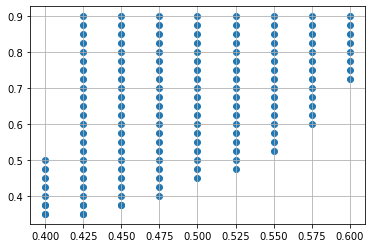

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [39]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [10]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
-------  42 0.4500000000000001 0.5500000000000003
-------  49 0.47500000000000014 0.5750000000000003
-------  56 0.5000000000000002 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  77 0.5000000000000002 0.6750000000000004
-------  84 0.5000000000000002 0.7000000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  98 0.47500000000000014 0.7500000000000004
-------  105 0.4500000000000001 0.7750000000000005
-------  112 0.4250000000000001 0.8000000000000005
-------  119 0.6000000000000003 0.8000000000000005
-------  126 0.5750000000000002 0.8250000000000005
-------  133 0.5500000000000003 0.8500000000

In [11]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140 147]


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  0 , total integrated cost =  5538.707762167343
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4000000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4642.275953194359
Gradient descend method:  None
RUN  0 , total integrated cost =  4642.275953194359
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.4500000000000002

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1597.4109736505836
RUN  2 , total integrated cost =  544.6226396183066
RUN  3 , total integrated cost =  381.64393949114054
RUN  4 , total integrated cost =  232.46534562869283
RUN  5 , total integrated cost =  143.00481133451007
RUN  6 , total integrated cost =  50.32419393467359
RUN  7 , total integrated cost =  40.21391216898711
RUN  8 , total integrated cost =  36.11072927592799
RUN  9 , total integrated cost =  33.83241770512282
RUN  10 , total integrated cost =  32.25388693191771
RUN  11 , total integrated cost =  30.799112161463725
RUN  12 , total integrated cost =  29.580580471902454
RUN  13 , total integrated cost =  28.42959908732252
RUN  14 , total integrated cost =  27.618464568325688
RUN  15 , total integrated co

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  1160 , total integrated cost =  14.687398360330363
Improved over  1160  iterations in  21.649926491081715  seconds by  99.7511625400251  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761732660856 -56.62761738404111
weight =  4018.6875404567027
set cost params:  1.0 0.0 4018.6875404567027
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5897.12118692169
Gradient descend method:  None
RUN  1 , total integrated cost =  5727.383546879708
RUN  2 , total integrated cost =  5723.75409551326
RUN  3 , total integrated cost =  5704.173737576396
RUN  4 , total integrated cost =  5696.350407954309
RUN  5 , total integrated cost =  5695.331620492974
RUN  6 , total integrated cost =  5662.097537733731
RUN  7 , total integrated cost =  5643.760550092104
RUN  8 , total integrated cost =  5643.68863767473
RUN  9 , total integrated cost =  5643.684040259936
RUN  10 , total integrated cost =  5643.68

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5643.683547740776
RUN  20 , total integrated cost =  5643.683547740775
Control only changes marginally.
RUN  21 , total integrated cost =  5643.683547740775
Improved over  21  iterations in  0.4457434359937906  seconds by  4.297650177903336  percent.
Problem in initial value trasfer:  Vmean_exc -56.627289320724316 -56.62728386309468
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  1 , total integrated cost =  1499.6965460155075
RUN  2 , total integrated cost =  1292.5341272865774
RUN  3 , total integrated cost =  1068.8668078148223
RUN  4 , total integrated cost =  909.5918879672716
RUN  5 , total integrated cost =  742.7541711298319
RUN  6 , total integrated cost =  630.739983623255
RUN  7 , total integrated cost =  482.0431201290164
RUN  8 , total integrated cost = 

...

RUN  8 , total integrated cost =  37667.25605886516
RUN  9 , total integrated cost =  37667.25605886516
Control only changes marginally.
RUN  9 , total integrated cost =  37667.25605886516
Improved over  9  iterations in  0.2649269588291645  seconds by  3.308203207443867  percent.
Problem in initial value trasfer:  Vmean_exc -56.69998930523515 -56.69998923915863
-------  126 0.5750000000000002 0.8250000000000005
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33632.4581250047
Gradient descend method:  None
RUN  1 , total integrated cost =  3633.116479487244
RUN  2 , total integrated cost =  3024.748532708155
RUN  3 , total integrated cost =  228.32033913358194
RUN  4 , total integrated cost =  90.40849784384312
RUN  5 , total integrated cost =  70.25734588961197
RUN  6 , total integrated cost =  63.91148746197668
RUN  7 , total integrated cost =  60.45567495381834
RUN  8 , total integrated cost =  58.9

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  33132.77759528316
Control only changes marginally.
RUN  14 , total integrated cost =  33132.77759528316
Improved over  14  iterations in  0.3451486323028803  seconds by  1.4708864149403666  percent.
Problem in initial value trasfer:  Vmean_exc -56.7034358072032 -56.7034357533006
-------  133 0.5500000000000003 0.8500000000000005
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28476.84043318933
Gradient descend method:  None
RUN  1 , total integrated cost =  5360.295564318014
RUN  2 , total integrated cost =  3360.15453661741
RUN  3 , total integrated cost =  2432.4758014312474
RUN  4 , total integrated cost =  1756.735240103995
RUN  5 , total integrated cost =  1354.727255658011
RUN  6 , total integrated cost =  1009.3822473219026
RUN  7 , total integrated cost =  783.6930212413511
RUN  8 , total integrated cost =  527.3615036934114
RUN  9 , total integrated cost =  3

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  27924.66436137807
Control only changes marginally.
RUN  51 , total integrated cost =  27924.66436137807
Improved over  51  iterations in  1.0789088234305382  seconds by  1.9270247827065248  percent.
Problem in initial value trasfer:  Vmean_exc -56.70401688114391 -56.704016853097194
-------  140 0.5250000000000001 0.8750000000000006
set cost params:  1.0 0.0 0.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Improved over  1  iterations in  0.05692555010318756  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control 

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


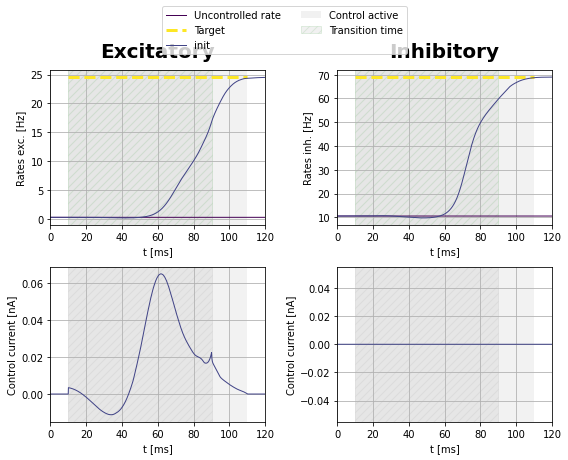

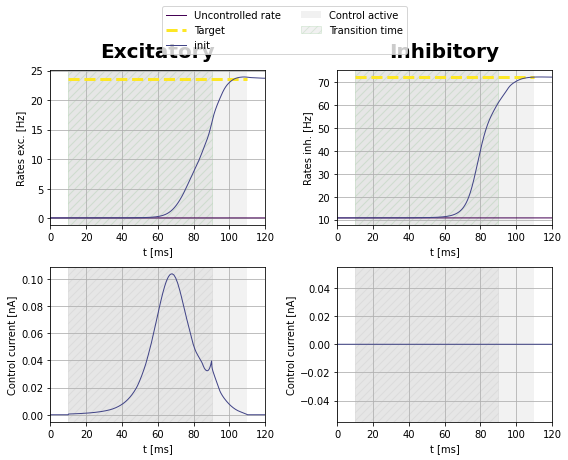

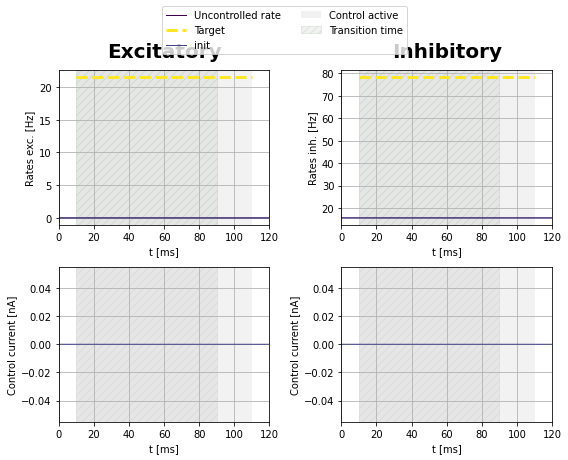

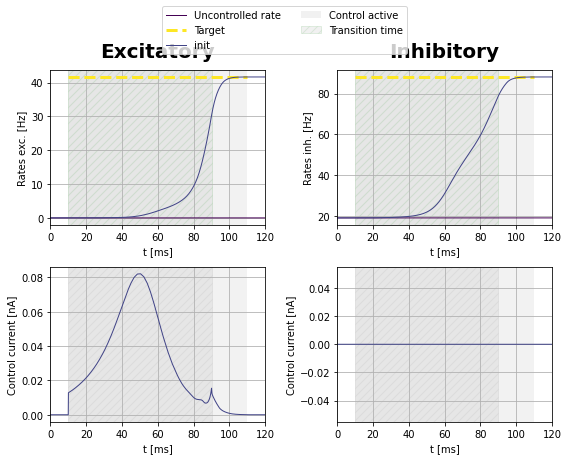

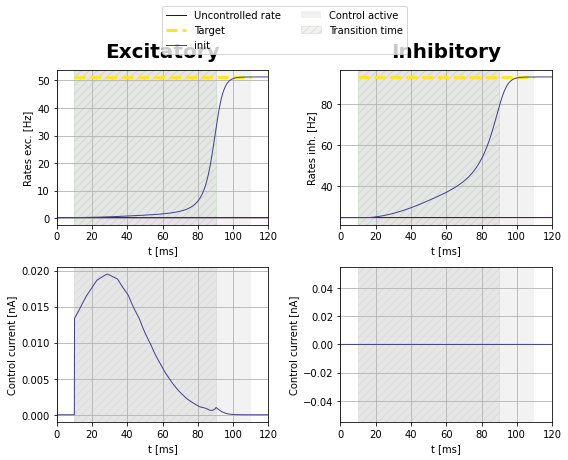

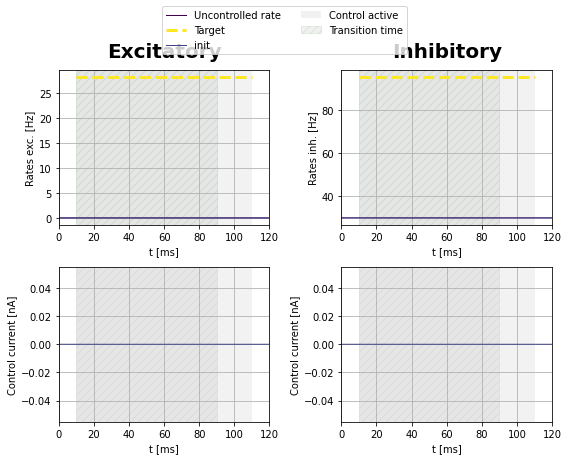

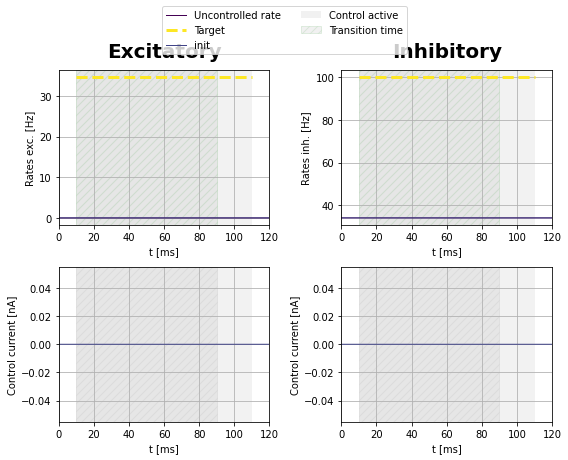

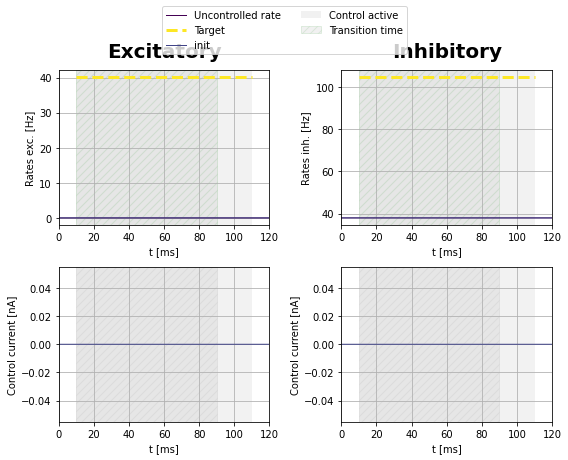

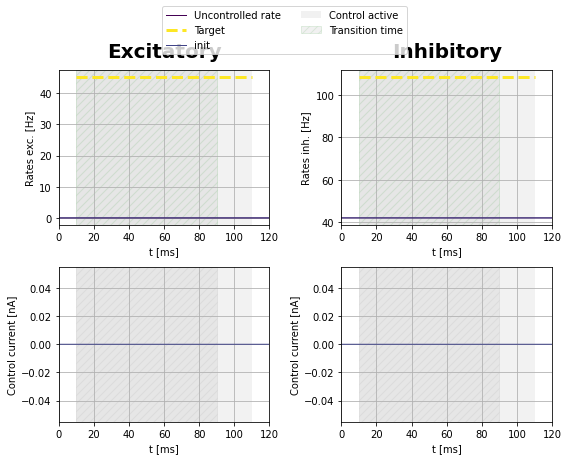

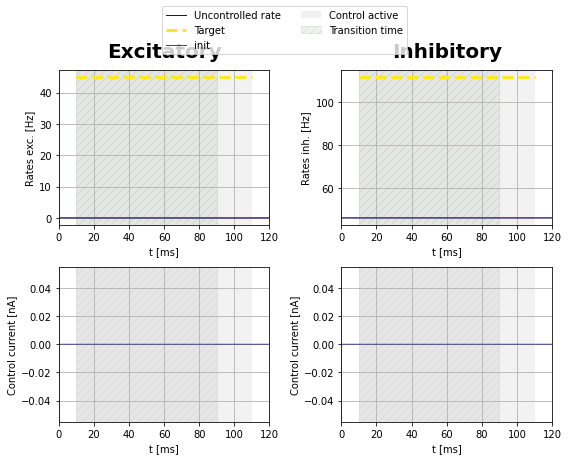

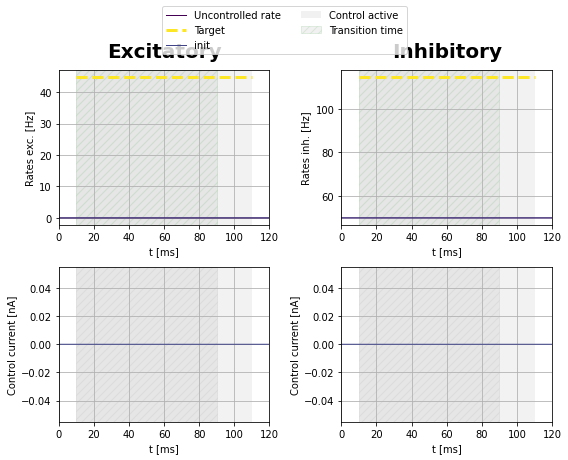

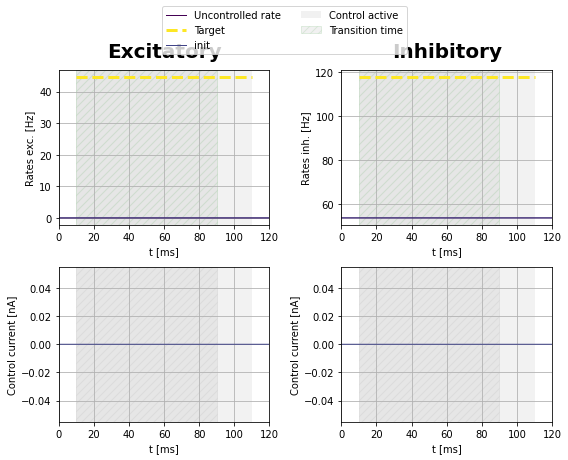

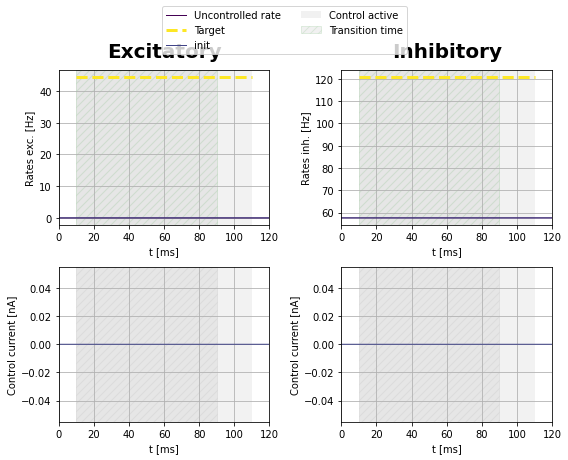

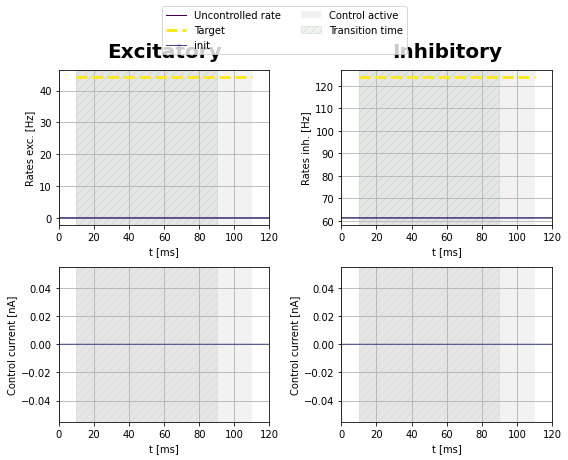

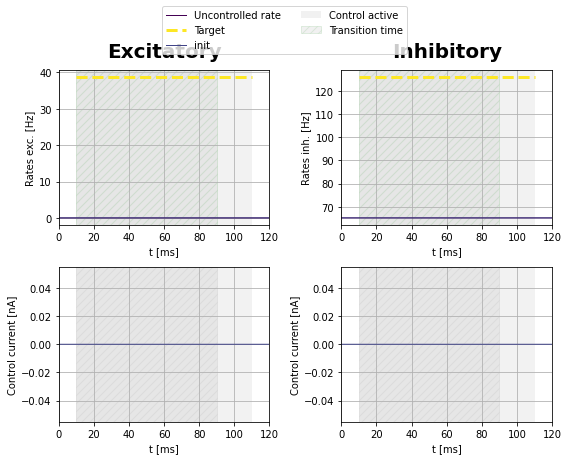

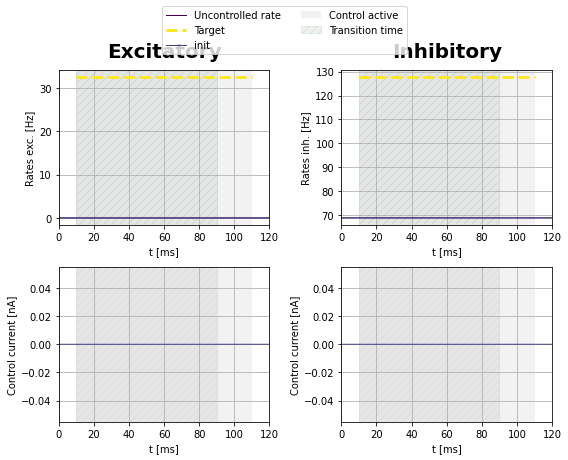

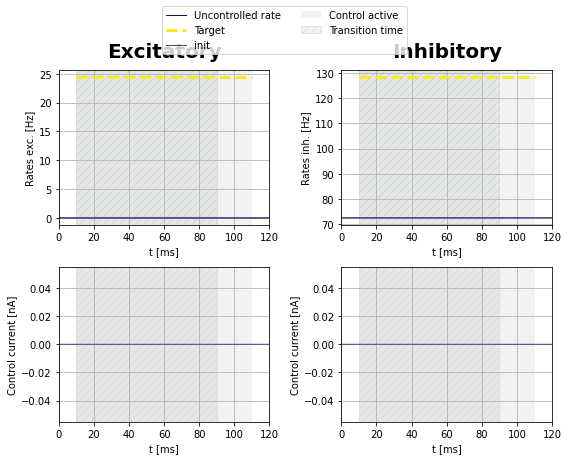

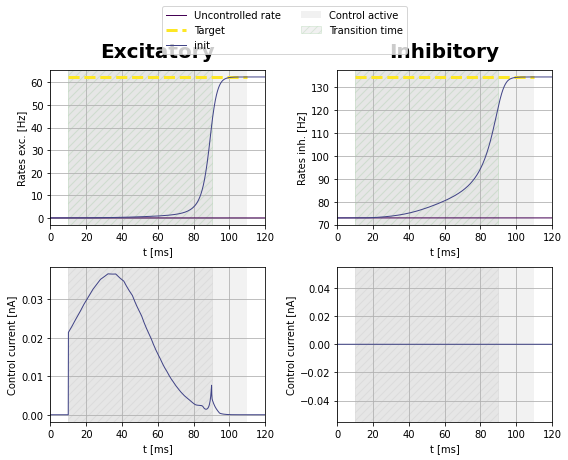

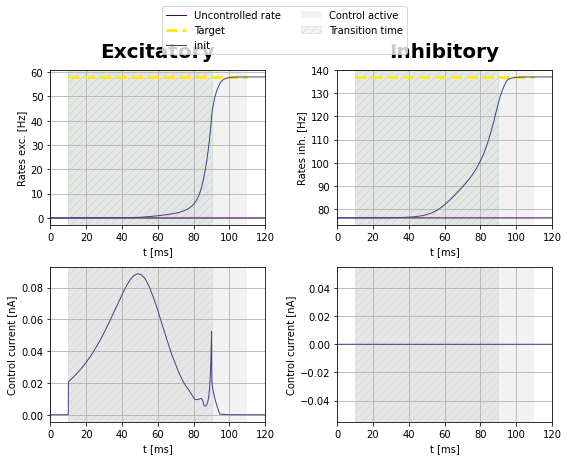

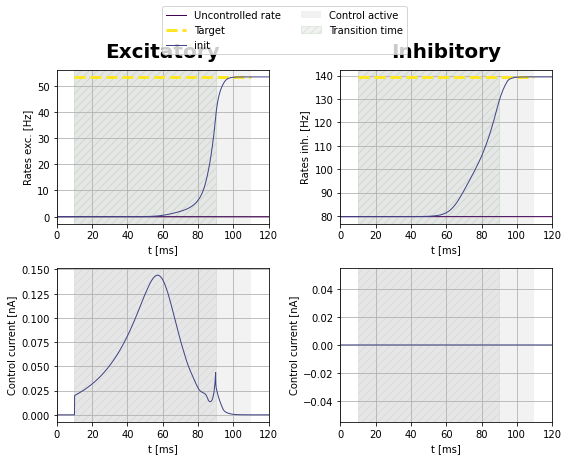

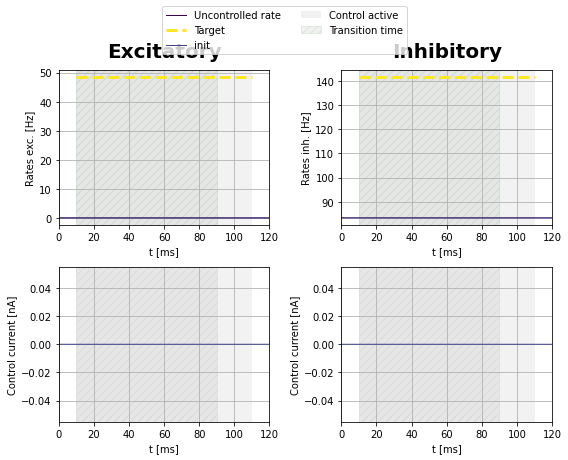

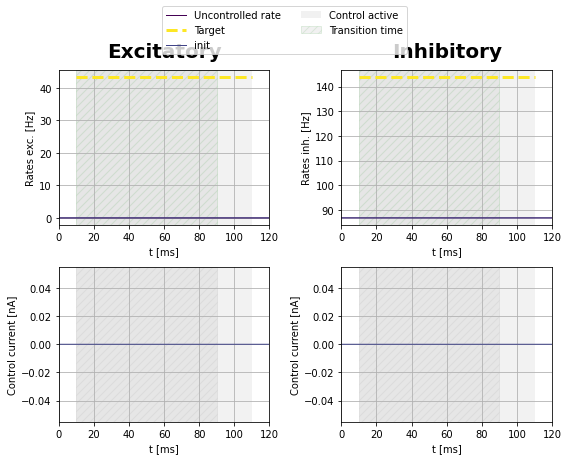

In [15]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
no solution found for  14
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4655.467951927492
Gradient descend method:  None
RUN  1 , total integrated cost =  4644.076761713759
RUN  2 , total integrated cost =  4642.324338382225
RUN  3 , total integrated cost =  4642.278064001878
RUN  4 , total integrated cost =  4642.276042651473
RUN  5 , total integrated cost =  4642.275955680608
RUN  6 , total integrated cost =  4642.275953220288
RUN  7 , total integrated cost =  4642.275953195053
RUN  8 , total integrated cost =  4642.275953194364
RUN  9 , total integrated cost =  4642.27595319436
RUN  10 , total integrated cost =  4642.275953194359
RUN  11 , total integrated cost =  4642.275953194359
Control only changes marginally.
RUN  11 , total integrated cost =  4642.275953194359
Improved over 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  112 , total integrated cost =  60.722396114093364
Improved over  112  iterations in  2.1874789632856846  seconds by  99.23890721902207  percent.
Problem in initial value trasfer:  Vmean_exc -56.637894957707694 -56.63789487360865
-------  42 0.4500000000000001 0.5500000000000003
no solution found for  42
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12023.071920459422
Gradient descend method:  None
RUN  1 , total integrated cost =  12017.603853755301
RUN  2 , total integrated cost =  12017.484018354966
RUN  3 , total integrated cost =  12017.48294136435
RUN  4 , total integrated cost =  12017.482908585216
RUN  5 , total integrated cost =  12017.48290763746
RUN  6 , total integrated cost =  12017.482907599624
RUN  7 , total integrated cost =  12017.482907599215
RUN  8 , total integrated cost =  12017.482907599211
RUN  9 , total integrated cost =  12017.48290759921
RUN  10 , total integrated cos

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  284 , total integrated cost =  48.50642058001054
Improved over  284  iterations in  5.396230898797512  seconds by  52.69039697988468  percent.
weight =  3326.7801039339215
set cost params:  1.0 0.0 3326.7801039339215
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16133.869625835843
Gradient descend method:  None
RUN  1 , total integrated cost =  16084.39997048031
RUN  2 , total integrated cost =  16084.39997048031
Control only changes marginally.
RUN  2 , total integrated cost =  16084.39997048031
Improved over  2  iterations in  0.09547497518360615  seconds by  0.3066199027437051  percent.
Problem in initial value trasfer:  Vmean_exc -56.68398594890224 -56.683988020734375
-------  56 0.5000000000000002 0.6000000000000003
no solution found for  56
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20429.67015529868
Gradient descend method:  None
RUN  1 , total integrated c

...

RUN  300 , total integrated cost =  47.04726498112062
Control only changes marginally.
RUN  307 , total integrated cost =  47.04726498112043
Improved over  307  iterations in  6.062920160591602  seconds by  99.80028009570223  percent.
Problem in initial value trasfer:  Vmean_exc -56.700677134049464 -56.70067714458048
weight =  5001.913746216147
set cost params:  1.0 0.0 5001.913746216147
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23530.831295631233
Gradient descend method:  None
RUN  1 , total integrated cost =  23502.312185916922
RUN  2 , total integrated cost =  23502.293356121983
RUN  3 , total integrated cost =  23502.2890532187
RUN  4 , total integrated cost =  23502.286834514496
RUN  5 , total integrated cost =  23502.284151267413
RUN  6 , total integrated cost =  23502.280528176736
RUN  7 , total integrated cost =  23502.26834037404
RUN  8 , total integrated cost =  23502.03077719701
RUN  9 , total integrated cost =  23499.47239428386
RUN  10 , total

ERROR:root:Problem in initial value trasfer


RUN  90 , total integrated cost =  23484.936518293613
Control only changes marginally.
RUN  95 , total integrated cost =  23484.936518293434
Improved over  95  iterations in  1.820913627743721  seconds by  0.19504103684734275  percent.
Problem in initial value trasfer:  Vmean_exc -56.70067269423444 -56.70067284641297
-------  147 0.5000000000000002 0.9000000000000006
no solution found for  147
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18835.968047811602
Gradient descend method:  None
RUN  1 , total integrated cost =  18800.93595414389
RUN  2 , total integrated cost =  694.5633872048553
RUN  3 , total integrated cost =  78.90940506703436
RUN  4 , total integrated cost =  65.4660786913925
RUN  5 , total integrated cost =  63.91005734927939
RUN  6 , total integrated cost =  63.41498551450696
RUN  7 , total integrated cost =  63.119194080708105
RUN  8 , total integrated cost =  62.90318746261755
RUN  9 , total integrated cost =  

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  18752.849480115878
Control only changes marginally.
RUN  47 , total integrated cost =  18752.849480115794
Improved over  47  iterations in  0.922643318772316  seconds by  0.24176480865905603  percent.
Problem in initial value trasfer:  Vmean_exc -56.691974745949395 -56.69197550892481


In [17]:
factor_iteration = 20
full_converge = False

while full_converge == False:
    
    if all(conv == True for conv in conv_init[::i_stepsize][0]):
        if all(conv == True for conv in conv_init[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  4201.915910535335
set cost params:  1.0 0.0 4201.915910535335
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.829633831054
Gradient descend method:  None
RUN  1 , total integrated cost =  5895.751169573142
RUN  2 , total integrated cost =  5895.74619608244
RUN  3 , total integrated cost =  5895.745864573096
RUN  4 , total integrated cost =  5895.745822677176
RUN  5 , total integrated cost =  5895.745816620723
RUN  6 , total integrated cost =  5895.745815724969
RUN  7 , total integrated cost =  5895.745815584775
RUN  8 , total integrated cost =  5895.745815564565
RUN  9 , total integrated cost =  5895.745815561753
RUN  10 , total integrated cost =  5895.745815561382
RUN  11 , total integrated cost =  5895.745815561334
RUN  12 , total integrated cost =  5895.745815561328
RUN  13 , total integrated cost =  5895.745815561326
RUN  14 , total integrated cost =  5895.745815561325
RUN  15 , t

ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.627211936890845 -56.627207332085455
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  2453.9541982442192
set cost params:  1.0 0.0 2453.9541982442192
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5534.317314614666
Gradient descend method:  None
RUN  1 , total integrated cost =  5534.3065749976895
RUN  2 , total integrated cost =  5534.305401580374
RUN  3 , total integrated cost =  5534.305174257879
RUN  4 , total integrated cost =  5534.30512669233
RUN  5 , total integrated cost =  5534.305121880515
RUN  6 , total integrated cost =  5534.305120861251
RUN  7 , total integrated cost =  5534.305120629748
RUN  8 , total integrated cost =  5534.305120582597
RUN  9 , total integrated cost =  5534.305120572597


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  5534.305120570551
RUN  11 , total integrated cost =  5534.305120570106
RUN  12 , total integrated cost =  5534.305120570002
RUN  13 , total integrated cost =  5534.305120569975
RUN  14 , total integrated cost =  5534.305120569971
RUN  15 , total integrated cost =  5534.305120569966
RUN  16 , total integrated cost =  5534.305120569963
RUN  17 , total integrated cost =  5534.305120569963
Control only changes marginally.
RUN  17 , total integrated cost =  5534.305120569963
Improved over  17  iterations in  0.37869476340711117  seconds by  0.0002203351201330861  percent.
Problem in initial value trasfer:  Vmean_exc -56.625925483727066 -56.625913298029595
-------  14 0.4000000000000001 0.42500000000000016
converged for  14
-------  21 0.47500000000000014 0.4500000000000002
no convergence
weight =  8444.616614000728
set cost params:  1.0 0.0 8444.616614000728
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17336.47949925443
Gradient 

...

RUN  2 , total integrated cost =  23527.94096054982
RUN  3 , total integrated cost =  23527.940960549815
RUN  4 , total integrated cost =  23527.94096054981
RUN  5 , total integrated cost =  23527.94096054981
Control only changes marginally.
RUN  5 , total integrated cost =  23527.94096054981
Improved over  5  iterations in  0.24499859102070332  seconds by  7.105427357601002e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.700672685227225 -56.70067283771596
-------  147 0.5000000000000002 0.9000000000000006
no convergence
weight =  3230.107735278933
set cost params:  1.0 0.0 3230.107735278933
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18793.975460461294
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  18793.975460461294
Control only changes marginally.
RUN  1 , total integrated cost =  18793.975460461294
Improved over  1  iterations in  0.06884880736470222  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.691974694393004 -56.69197545882465
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  4205.740665933485
set cost params:  1.0 0.0 4205.740665933485
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.0033521146415
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.0033521146415
Control only changes marginally.
RUN  1 , total integrated cost =  5901.0033521146415
Improved over  1  iterations in  0.06806785054504871  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62721023575119 -56.62720564975733
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  2454.9197086042154
set cost params:  1.0 0.0 2454.9197086042154

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  10552.235577823558
Gradient descend method:  None
RUN  1 , total integrated cost =  10552.235577823558
Control only changes marginally.
RUN  1 , total integrated cost =  10552.235577823558
Improved over  1  iterations in  0.07242885231971741  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65547654749692 -56.655473519884616
-------  112 0.4250000000000001 0.8000000000000005
converged for  112
-------  119 0.6000000000000003 0.8000000000000005
converged for  119
-------  126 0.5750000000000002 0.8250000000000005
converged for  126
-------  133 0.5500000000000003 0.8500000000000005
converged for  133
-------  140 0.5250000000000001 0.8750000000000006
no convergence
weight =  5011.081229643778
set cost params:  1.0 0.0 5011.081229643778
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23527.94096058097
Gradient descend method:  None
RUN  1 , total integrated cost =  23527.94096058097
Control only changes m

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [19]:
factor_iteration = 20
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  133.6093796567415
Gradient descend method:  None
RUN  1 , total integrated cost =  24.6204774467671
RUN  2 , total integrated cost =  21.820260165997126
RUN  3 , total integrated cost =  19.620269652666195
RUN  4 , total integrated cost =  18.65562697456294
RUN  5 , total integrated cost =  17.66330157477423
RUN  6 , total integrated cost =  17.12023721630298
RUN  7 , total integrated cost =  16.458413479379196
RUN  8 , total integrated cost =  16.067780715574482
RUN  9 , total integrated cost =  15.507612608367378
RUN  10 , total integrated cost =  15.240869980624034
RUN  11 , total integrated cost =  14.758365456651333
RUN  12 , total integrated cost =  14.718731734106187
RUN  13 , total integrated cost =  14.6935971073422
RUN  14 , total integrated cost =  14.669891517528908
RUN  15 , total integrated cost =  14.65477722930757
RUN  1

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  13.91467045280809
RUN  1000 , total integrated cost =  13.91467045280809
Improved over  1000  iterations in  43.99045469611883  seconds by  89.58555867218563  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762124337215 -56.62762122208333
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  139.05262250457963
Gradient descend method:  HS
RUN  1 , total integrated cost =  138.8344060794356
RUN  2 , total integrated cost =  138.56066146445139
RUN  3 , total integrated cost =  138.5484888486968
RUN  4 , total integrated cost =  138.4746409863408
RUN  5 , total integrated cost =  138.46578928547422
RUN  6 , total integrated cost =  138.4490699240883
RUN  7 , total integrated cost =  138.42939027517565
RUN  8 , total integrated cost =  138.41238917705442
RUN  9 , total integrated cost =  138.38777551975843
RUN  10 , total integrated cost =  137.79702722774155
RUN  11 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  704 , total integrated cost =  123.68649095508775
Improved over  704  iterations in  46.502159900963306  seconds by  11.050587376721936  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762421939393 -56.62762423676529
weight =  4771.070444929695
set cost params:  1.0 0.0 4771.070444929695
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5893.761906187593
Gradient descend method:  None
RUN  1 , total integrated cost =  5824.16904120005
RUN  2 , total integrated cost =  5816.999622277113
RUN  3 , total integrated cost =  5808.817696230059
RUN  4 , total integrated cost =  5793.149326233835
RUN  5 , total integrated cost =  5772.49624568562
RUN  6 , total integrated cost =  5770.828362396815
RUN  7 , total integrated cost =  5519.017234539645
RUN  8 , total integrated cost =  5426.679681818367
RUN  9 , total integrated cost =  5357.47908414901
RUN  10 , total integrated cost =  5314.998139653852
RUN  11 , total integr

...

Control only changes marginally.
RUN  115 , total integrated cost =  58.29944192963196
Improved over  115  iterations in  11.525310492143035  seconds by  32.56237540534384  percent.
Problem in initial value trasfer:  Vmean_exc -56.69200245566384 -56.692002543763486
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  582.9454690789659
Gradient descend method:  HS
RUN  1 , total integrated cost =  582.8969032795942
RUN  2 , total integrated cost =  582.5136219218385
RUN  3 , total integrated cost =  581.9992760374743
RUN  4 , total integrated cost =  581.7876212493138
RUN  5 , total integrated cost =  581.7762621270442
RUN  6 , total integrated cost =  581.7380472340731
RUN  7 , total integrated cost =  581.6937085401153
RUN  8 , total integrated cost =  581.6935443118668
RUN  9 , total integrated cost =  581.6931484490922
RUN  10 , total integrated cost =  581.6898485169978
RUN  11 , total integrated cost =  581.642094240

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  43 , total integrated cost =  580.5542560199027
Improved over  43  iterations in  4.734089275822043  seconds by  0.4101949815033663  percent.
Problem in initial value trasfer:  Vmean_exc -56.69204847527904 -56.692046430926496
weight =  3237.249248859646
set cost params:  1.0 0.0 3237.249248859646
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18783.340970743408
Gradient descend method:  None
RUN  1 , total integrated cost =  18762.51001019745


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  18762.510010197442
RUN  3 , total integrated cost =  18762.510010197442
Control only changes marginally.
RUN  3 , total integrated cost =  18762.510010197442
Improved over  3  iterations in  0.4504134524613619  seconds by  0.11090125328827583  percent.
Problem in initial value trasfer:  Vmean_exc -56.69201943762372 -56.69201825497682


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


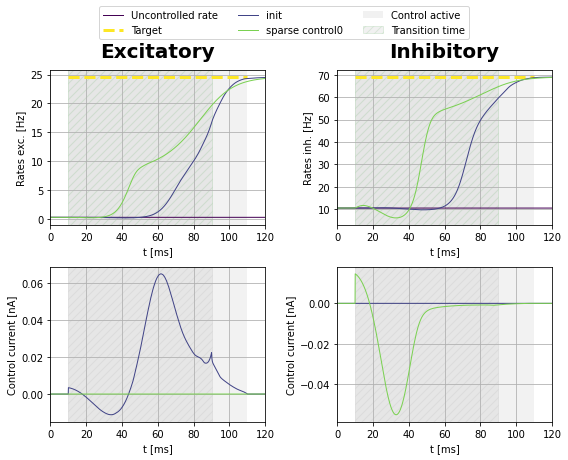

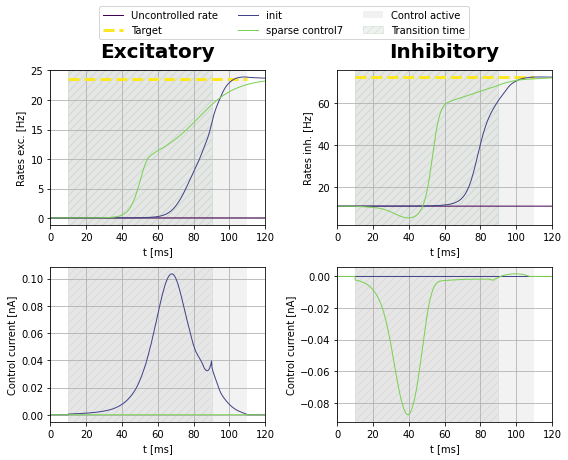

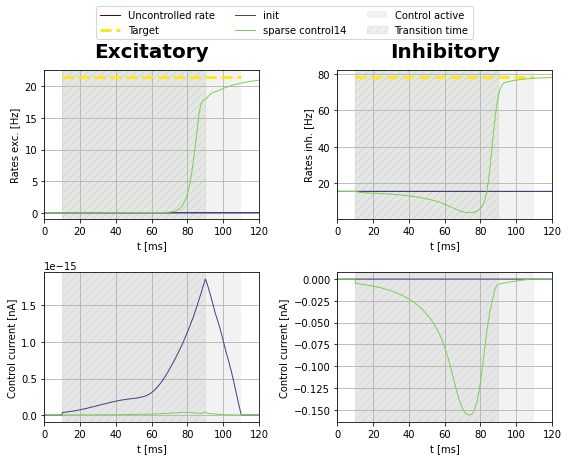

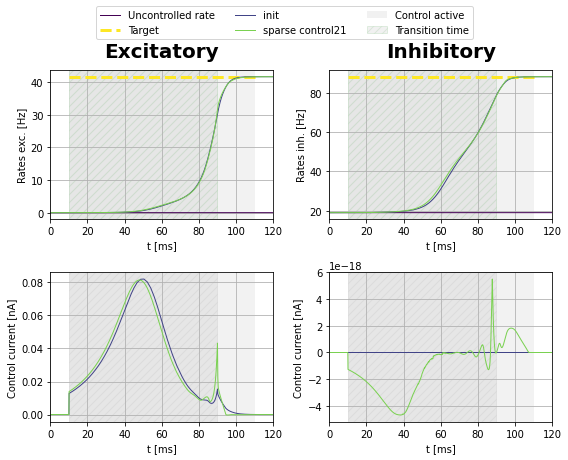

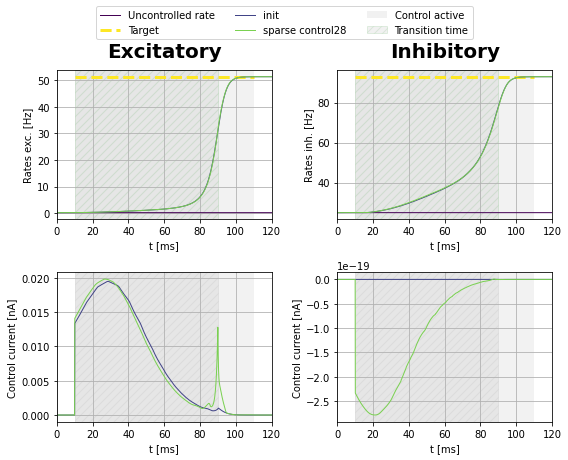

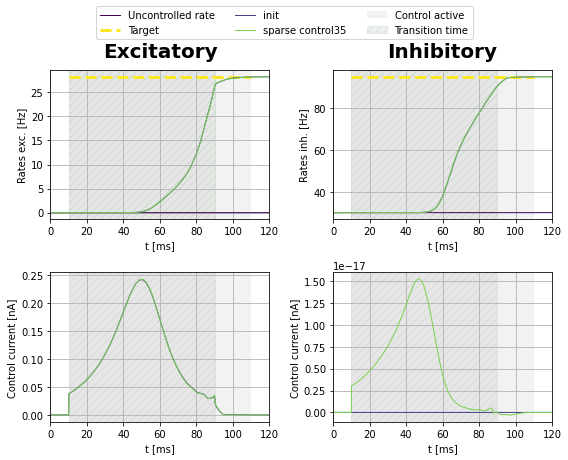

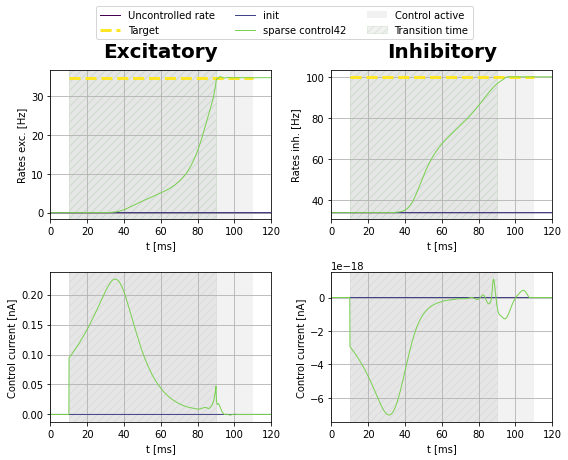

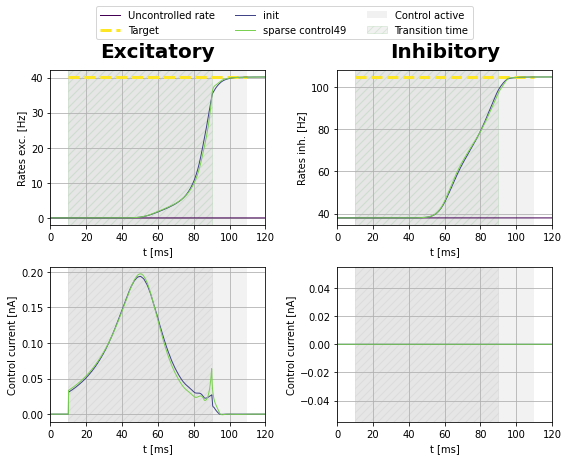

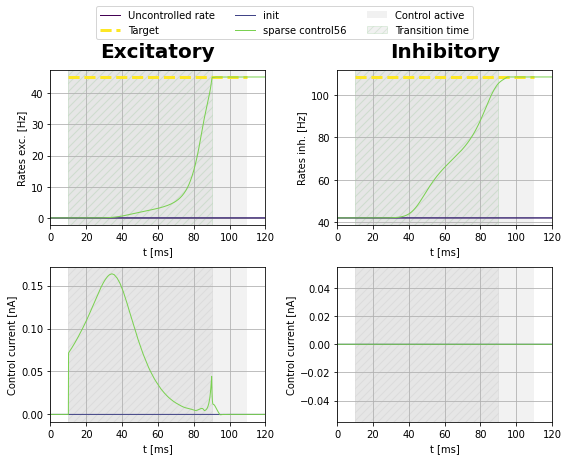

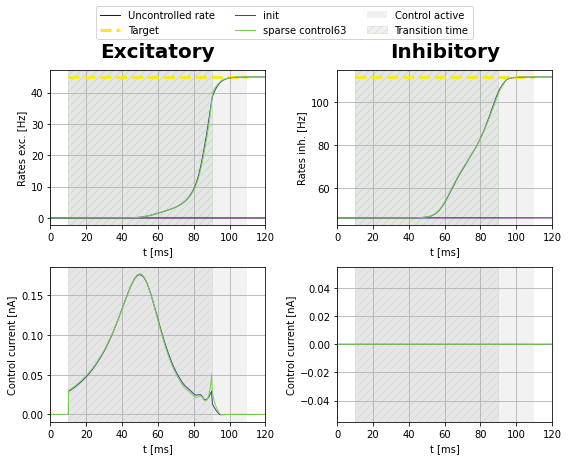

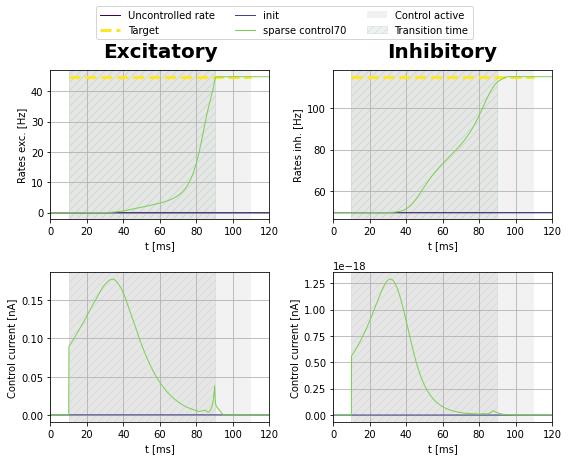

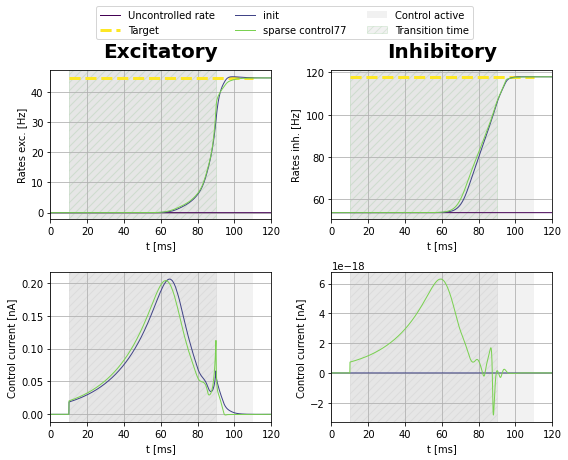

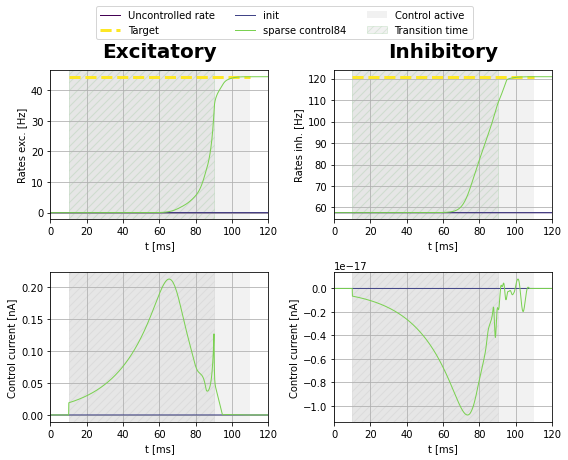

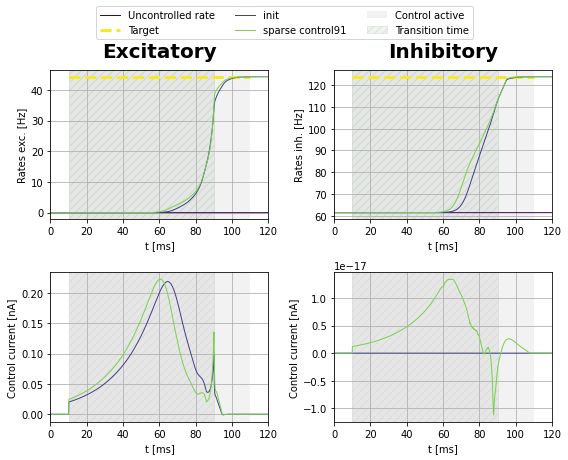

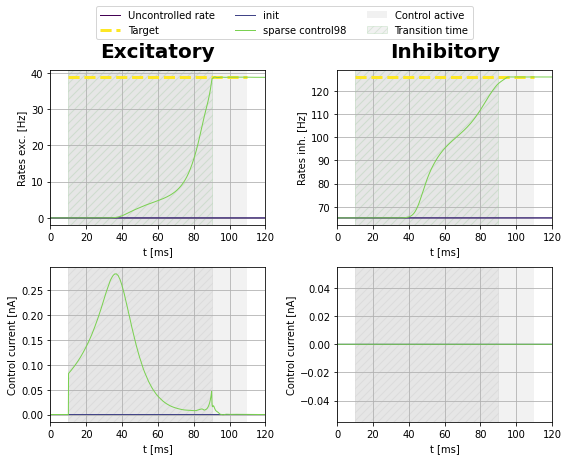

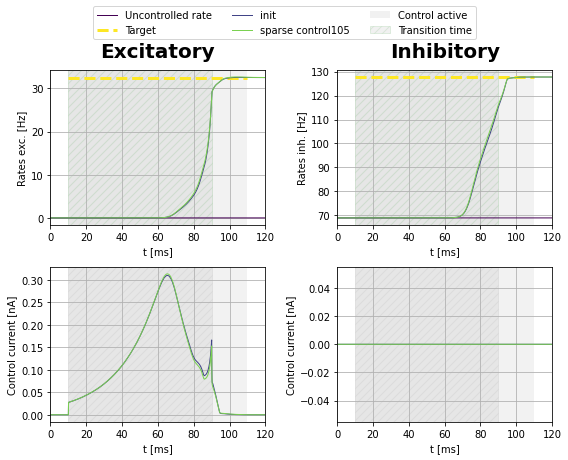

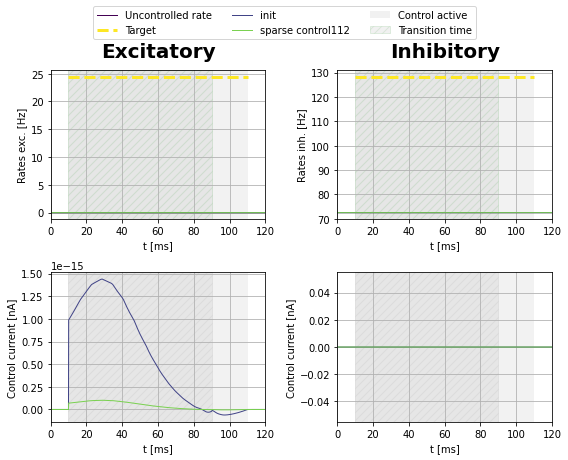

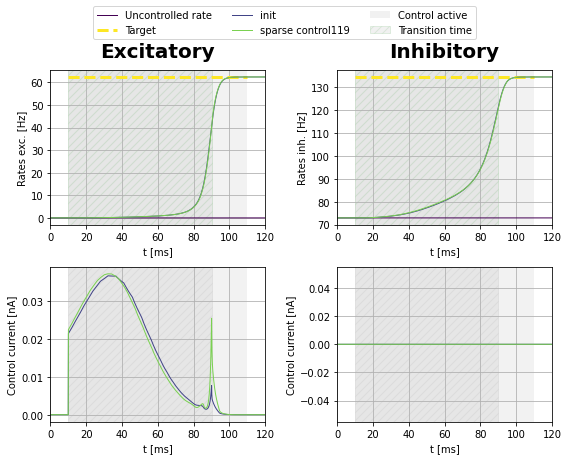

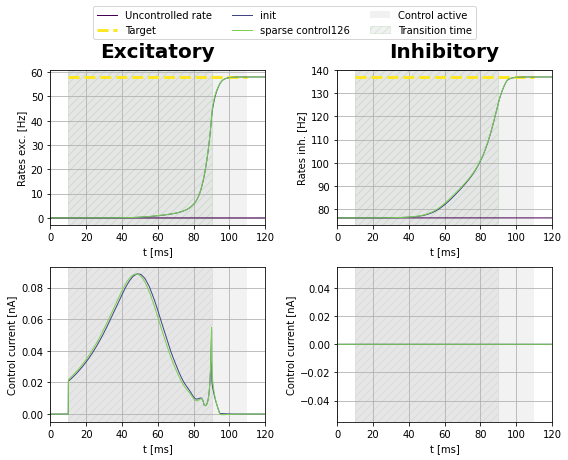

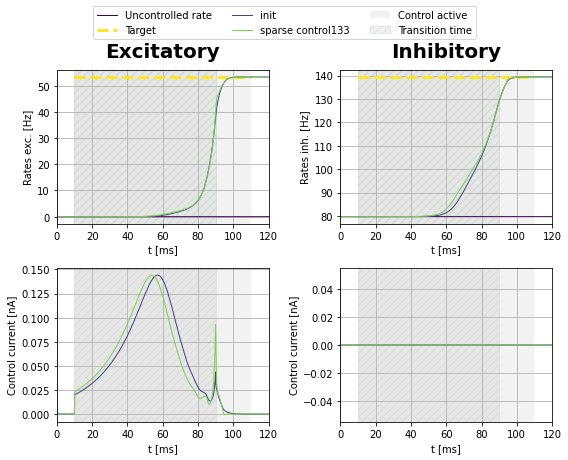

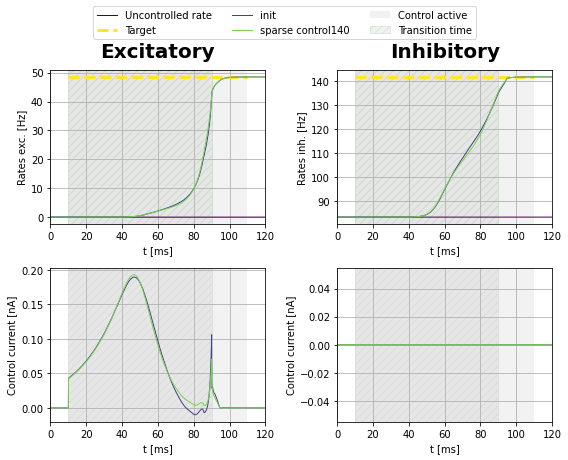

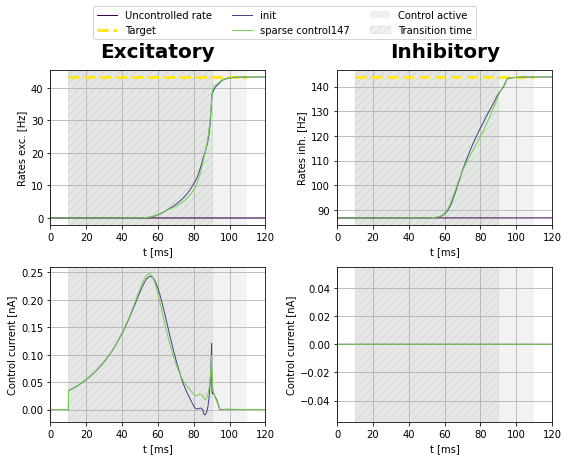

In [20]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [21]:
factor_iteration = 20
full_converge = False

while full_converge ==  False:
    
    if all(conv == True for conv in conv_0[::i_stepsize][0]):
        if all(conv == True for conv in conv_0[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
    

-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  5834.929109305077
set cost params:  1.0 0.0 5834.929109305077
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5885.6062889487
Gradient descend method:  None
RUN  1 , total integrated cost =  5884.499417636613
RUN  2 , total integrated cost =  5884.499416605486
RUN  3 , total integrated cost =  5884.499416603682
RUN  4 , total integrated cost =  5884.499416603664
RUN  5 , total integrated cost =  5884.499416603663


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5884.499416603663
Control only changes marginally.
RUN  6 , total integrated cost =  5884.499416603663
Improved over  6  iterations in  0.868356017395854  seconds by  0.01880642861068793  percent.
Problem in initial value trasfer:  Vmean_exc -56.62640547062653 -56.62641509957497
-------  7 0.4000000000000001 0.3750000000000001
no convergence
weight =  3401.1942659175693
set cost params:  1.0 0.0 3401.1942659175693
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5518.732609282001
Gradient descend method:  None
RUN  1 , total integrated cost =  5518.148443314165
RUN  2 , total integrated cost =  5518.148148439421
RUN  3 , total integrated cost =  5518.14814537424
RUN  4 , total integrated cost =  5518.1481453583
RUN  5 , total integrated cost =  5518.148145358186


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5518.148145358183
RUN  7 , total integrated cost =  5518.148145358183
Control only changes marginally.
RUN  7 , total integrated cost =  5518.148145358183
Improved over  7  iterations in  0.8694290593266487  seconds by  0.010590546148876001  percent.
Problem in initial value trasfer:  Vmean_exc -56.62510986983504 -56.62511191032121
-------  14 0.4000000000000001 0.42500000000000016
no convergence
weight =  1387.6879293724824
set cost params:  1.0 0.0 1387.6879293724824
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4638.446063817089
Gradient descend method:  None


...

RUN  1 , total integrated cost =  17338.849855326243
Control only changes marginally.
RUN  1 , total integrated cost =  17338.849855326243
Improved over  1  iterations in  0.19440984912216663  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.688428174307774 -56.68843120249126
-------  28 0.5250000000000001 0.4750000000000002
converged for  28
-------  35 0.4250000000000001 0.5250000000000002
converged for  35
-------  42 0.4500000000000001 0.5500000000000003
converged for  42
-------  49 0.47500000000000014 0.5750000000000003
converged for  49
-------  56 0.5000000000000002 0.6000000000000003
converged for  56
-------  63 0.5000000000000002 0.6250000000000003
converged for  63
-------  70 0.5000000000000002 0.6500000000000004
no convergence
weight =  4347.130298461025
set cost params:  1.0 0.0 4347.130298461025
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20066.49908012842
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  20066.49908012842
Control only changes marginally.
RUN  1 , total integrated cost =  20066.49908012842
Improved over  1  iterations in  0.19748476147651672  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69521229222487 -56.695211067185355
-------  77 0.5000000000000002 0.6750000000000004
converged for  77
-------  84 0.5000000000000002 0.7000000000000004
converged for  84
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  98 0.47500000000000014 0.7500000000000004
converged for  98
-------  105 0.4500000000000001 0.7750000000000005
converged for  105
-------  112 0.4250000000000001 0.8000000000000005
converged for  112
-------  119 0.6000000000000003 0.8000000000000005
converged for  119
-------  126 0.5750000000000002 0.8250000000000005
converged for  126
-------  133 0.5500000000000003 0.8500000000000005
converged for  133
-------  140 0.5250000000000001 0.8750000000000006
converged for  140
------

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5537.085421544267
Control only changes marginally.
RUN  1 , total integrated cost =  5537.085421544267
Improved over  1  iterations in  0.19464794546365738  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.625109634203724 -56.62511167387647
-------  14 0.4000000000000001 0.42500000000000016
converged for  14
-------  21 0.47500000000000014 0.4500000000000002
converged for  21
-------  28 0.5250000000000001 0.4750000000000002
converged for  28
-------  35 0.4250000000000001 0.5250000000000002
converged for  35
-------  42 0.4500000000000001 0.5500000000000003
converged for  42
-------  49 0.47500000000000014 0.5750000000000003
converged for  49
-------  56 0.5000000000000002 0.6000000000000003
converged for  56
-------  63 0.5000000000000002 0.6250000000000003
converged for  63
-------  70 0.5000000000000002 0.6500000000000004
converged for  70
-------  77 0.5000000000000002 0.6750000000000004
converged for  77
-------  84 0.50

In [22]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)